In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.nice(19)

19

In [118]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as pl
from astropy import constants as c
%matplotlib inline

#styling
import seaborn as sns
sns.set_style(style='ticks', rc=None)
sns.set_style({"xtick.direction": "in","ytick.direction": "in"})

matplotlib.rcParams.update({'font.size': 13})
pl.rcParams['ytick.labelsize'] = 'medium'
pl.rcParams['xtick.labelsize'] =  'medium'

In [43]:
#df_all=pd.read_csv('data/PS_2025.01.07_21.46.16_all.csv', skiprows=295, delimiter=',',na_values=[''])

#default parameter set ==1で選択している
df_all=pd.read_csv('data/PS_2026.01.29_00.14.43.csv', skiprows=296, delimiter=',',na_values=[''])
df_all["releasedate"] = pd.to_datetime(df_all["releasedate"])
df_all = df_all[df_all["releasedate"] <= "2023-12-31"]
df_all.head()

,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,sy_snum,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,2,...,2023-09-19,2023-08,2023-09-19,2,1,2,0,0,0,0
1,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,1,...,2018-09-04,2017-03,2018-09-06,0,1,1,0,0,0,0
2,14 And b,14 And,b,HD 221345,HIP 116076,TIC 333225860,Gaia DR2 1920113512486282240,Gaia DR3 1920113512486282240,1,1,...,2023-09-19,2023-08,2023-09-19,0,1,1,0,0,0,0
3,14 Her b,14 Her,b,HD 145675,HIP 79248,TIC 219483057,Gaia DR2 1385293808145621504,Gaia DR3 1385293808145621504,1,1,...,2023-06-12,2022-09,2023-06-12,0,1,4,1,0,0,0
4,16 Cyg B b,16 Cyg B,b,HD 186427,HIP 96901,TIC 27533327,Gaia DR2 2135550755683407232,Gaia DR3 2135550755683407232,1,3,...,2018-09-04,2017-03,2018-09-06,5,1,4,3,0,0,0


In [44]:
len(df_all)

5205

In [45]:
df_toi=pd.read_csv('data/tois_ExoFOP_2026_2_26.csv', skiprows=0, delimiter=',',na_values=[''])
df_toi

,TIC ID,Imaging Observations,Spectroscopy Observations,Time Series Observations,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,...,Stellar Radius (R_Sun) err,Stellar Metallicity,Stellar Metallicity err,Stellar Mass (M_Sun),Stellar Mass (M_Sun) err,Sectors,Comments,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified
0,231663901,3,1,0,101.01,NaN,5,5,5,5,...,0.043847,NaN,NaN,1.050000,0.129454,"1,27,67",WASP-46 b,2018-09-05,2024-09-06,2025-07-31
1,149603524,1,2,1,102.01,NaN,5,5,5,5,...,0.050000,0.240000,0.050000,1.280000,0.190812,"1,2,3,4,6,7,8,9,10,11,12,13,27,28,29,30,31,32,...",WASP 62 b,2019-05-07,2024-10-02,2025-07-31
2,336732616,7,0,0,103.01,NaN,5,5,5,5,...,NaN,NaN,NaN,1.270000,0.196969,1,HATS-3 b,2018-09-05,2024-09-06,2025-07-31
3,231670397,3,0,1,104.01,NaN,5,5,5,5,...,0.102573,NaN,NaN,1.160000,0.166129,"1,27,67",WASP-73 b,2018-09-05,2023-10-16,2025-07-31
4,144065872,2,3,1,105.01,NaN,5,5,5,5,...,0.059699,NaN,NaN,1.030000,0.127209,"1,28",WASP-95; epoch kept from qlp-s28-tois,2018-09-05,2025-03-25,2025-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7885,33945661,0,0,0,7685.01,TIC 33945661.01,3,4,3,3,...,NaN,NaN,NaN,0.920000,NaN,96,CTOI from Thomas Kaye; three of seven transits...,2026-01-15,2026-01-15,2026-02-01
7886,273861354,0,0,0,7686.01,TIC 273861354.01,3,4,3,3,...,0.020476,NaN,NaN,0.644006,0.020537,96,CTOI from Marco Montalto; low SNR,2026-01-15,2026-01-15,2026-02-01
7887,51992761,0,0,0,7687.01,TIC 51992761.01,3,4,3,3,...,0.071236,0.425938,0.063925,1.000000,0.119255,"95,96",CTOI from Rafael Rodrigues (Planet Hunters TES...,2026-01-15,2026-01-15,2026-02-01
7888,80429950,0,0,0,7688.01,TIC 80429950.01,2,4,2,2,...,0.012620,NaN,NaN,0.412676,0.020387,96,CTOI from Marco Montalto; low SNR; L1 candidate,2026-01-15,2026-01-15,2026-02-01


In [46]:
toi_list = [
"TOI4863.01","TOI5176.01","TOI5389.01","TOI5464.01","TOI5561.01",
"TOI5573.01","TOI5610.01","TOI5641.01","TOI5658.01","TOI5683.01",
"TOI5688.01","TOI5694.01","TOI5695.01","TOI5836.01","TOI5859.01",
"TOI5896.01","TOI6449.01","TOI7015.01"
]

# "TOI" を外して float に
toi_num = [float(t.replace("TOI","")) for t in toi_list]

df_sel = df_toi[df_toi["TOI"].isin(toi_num)]
df_sel

,TIC ID,Imaging Observations,Spectroscopy Observations,Time Series Observations,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,...,Stellar Radius (R_Sun) err,Stellar Metallicity,Stellar Metallicity err,Stellar Mass (M_Sun),Stellar Mass (M_Sun) err,Sectors,Comments,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified
5008,143032776,2,1,2,4863.01,NaN,3,4,3,3,...,0.010000,NaN,NaN,0.442985,0.021104,36,found in faint-star QLP search,2021-12-21,2024-08-22,2025-07-31
5327,437054764,1,3,2,5176.01,NaN,3,4,3,3,...,0.016876,NaN,NaN,0.535338,0.020869,"44,45,46",first event near start of orbit; also a K2 PC,2022-02-08,2022-07-15,2026-01-10
5540,39143128,1,0,8,5389.01,NaN,3,4,4,3,...,0.014176,NaN,NaN,0.415445,0.021552,48,NaN,2022-03-24,2022-03-24,2025-07-31
5617,171646471,0,2,7,5464.01,NaN,3,4,4,3,...,0.020000,NaN,NaN,0.524583,0.021607,"45,48",found in faint-star QLP search,2022-04-20,2024-08-22,2025-07-31
5721,330637910,2,1,4,5561.01,NaN,3,4,4,3,...,0.017253,NaN,NaN,0.488530,0.022309,"44,45,46",V-shaped; K2 candidate EPIC 211546613.01,2022-05-17,2022-05-17,2025-07-31
5734,459762279,2,1,3,5573.01,NaN,3,5,5,3,...,0.020000,NaN,NaN,0.583474,0.020395,47,found in faint-star QLP search,2022-05-17,2024-08-22,2025-07-31
5771,252481136,0,1,4,5610.01,NaN,3,4,4,3,...,0.020000,NaN,NaN,0.507479,0.021147,48,found in faint-star QLP search,2022-05-17,2024-08-22,2025-07-31
5806,141202786,1,2,6,5641.01,NaN,3,4,4,3,...,0.020000,NaN,NaN,0.473933,0.025830,49,found in faint-star QLP search,2022-06-02,2024-08-22,2025-07-31
5823,119178132,1,1,5,5658.01,NaN,3,4,4,3,...,0.020000,NaN,NaN,0.613865,0.021240,50,found in faint-star QLP search,2022-06-02,2024-08-22,2025-07-31
5848,155949264,0,1,3,5683.01,NaN,3,4,4,3,...,0.090000,NaN,NaN,0.623063,0.066696,"50,51",found in faint-star QLP search,2022-07-14,2024-08-22,2025-07-31


In [47]:
df_all = df_all[
    (df_all['pl_massj'] < 20) | (df_all['pl_massj'].isna()) #褐色矮星質量を除く
]

df_all = df_all[df_all['pl_controv_flag']==0]  #controversialを除く
len(df_all)

5138

### luminosity情報のある星が少ない！ => Stefan-Boltzmannから出す
本当はSEDでFbolを出すと一番いいらしい

In [48]:
from astropy import constants as ascon
ascon.sigma_sb

<<class 'astropy.constants.codata2018.CODATA2018'> name='Stefan-Boltzmann constant' value=5.6703744191844314e-08 uncertainty=0.0 unit='W / (K4 m2)' reference='CODATA 2018'>

In [49]:
sb = ascon.sigma_sb.value
Rsun = ascon.R_sun.value
Lsun = ascon.L_sun.value

df_all['st_lum_calc']=np.log10(4 * np.pi  * (df_all['st_rad']*Rsun)**2 * sb * df_all['st_teff']**4  /Lsun)

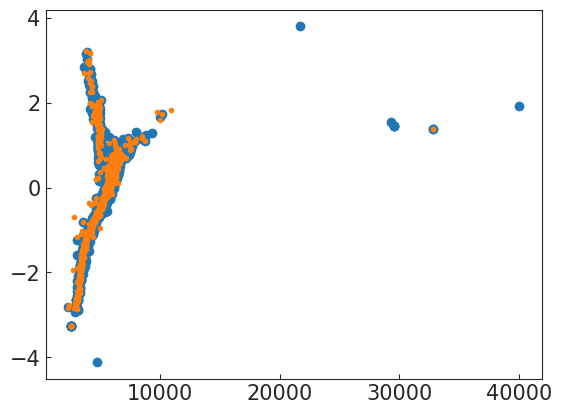

In [50]:
pl.plot(df_all['st_teff'], df_all['st_lum_calc'], 'o')
pl.plot(df_all['st_teff'], df_all['st_lum'], '.')

ok!

In [51]:
#detection method
df_transit = df_all[df_all['discoverymethod']=='Transit']
df_other = df_all[df_all['discoverymethod']!='Transit']
df_rv = df_all[df_all['discoverymethod']=='Radial Velocity']
df_mic = df_all[df_all['discoverymethod']=='Microlensing']

In [52]:
df_M = df_transit[df_transit['st_mass']<0.63]

In [84]:
df_M[df_M['pl_radj']>0.5]

,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,sy_snum,...,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,st_lum_calc
485,HATS-6 b,HATS-6,b,NaN,NaN,TIC 33521996,Gaia DR2 2966680597368750720,Gaia DR3 2966680597368750720,1,1,...,2015-05,2015-05-14,0,0,0,0,0,0,0,-1.249518
498,HATS-71 b,HATS-71,b,NaN,NaN,TIC 234523599,Gaia DR2 4710594412266148352,Gaia DR3 4710594412266148352,1,1,...,2020-06,2020-09-24,0,0,0,0,0,0,0,-1.557437
500,HATS-74 A b,HATS-74 A,b,NaN,NaN,TIC 219189765,Gaia DR2 3545653561942122368,Gaia DR3 3545653561942122368,1,2,...,2022-03,2021-12-13,0,0,0,0,0,0,0,-1.216221
501,HATS-75 b,HATS-75,b,NaN,NaN,TIC 44737596,Gaia DR2 5082914338199586560,Gaia DR3 5082914338199586560,1,1,...,2022-03,2021-12-13,0,0,0,0,0,0,0,-1.196551
1789,K2-387 b,K2-387,b,NaN,NaN,TIC 376938120,Gaia DR2 2580505553613124992,Gaia DR3 2580505553613124992,1,1,...,2022-03,2022-03-16,0,0,0,0,0,0,0,-1.299349
1832,K2-45 b,K2-45,b,NaN,NaN,TIC 38087018,Gaia DR2 3790858845506203264,Gaia DR3 3790858845506203264,1,1,...,2016-09,2016-07-18,0,0,0,0,0,0,0,-1.296180
2955,Kepler-1624 b,Kepler-1624,b,NaN,NaN,TIC 137683938,Gaia DR2 2051815759742763264,Gaia DR3 2051815759742763264,1,1,...,2016-05,2016-05-10,1,0,0,0,0,0,0,-1.458615
2959,Kepler-1628 b,Kepler-1628,b,NaN,NaN,TIC 123362984,Gaia DR2 2105245187265625728,NaN,1,1,...,2016-05,2016-05-10,1,0,0,0,0,0,0,-1.329261
3424,Kepler-1984 b,Kepler-1984,b,NaN,NaN,TIC 137089954,Gaia DR2 2101508501301083520,Gaia DR3 2101508501301083520,1,1,...,2017-08-31 00:00,2017-05-08,0,0,0,0,0,0,0,-1.555357
4110,Kepler-45 b,Kepler-45,b,NaN,NaN,TIC 137899948,Gaia DR2 2053562475706063744,Gaia DR3 2053562475706063744,1,1,...,2012-05,2014-05-14,1,0,0,0,0,0,0,-1.236327


In [54]:
df_sel['Stellar Mass (M_Sun)']

5008    0.442985
5327    0.535338
5540    0.415445
5617    0.524583
5721    0.488530
5734    0.583474
5771    0.507479
5806    0.473933
5823    0.613865
5848    0.623063
5853    0.569725
5859    0.607411
5860    0.344323
6006    0.400431
6029    0.610297
6066    0.570613
6630    0.451014
7207    0.462913
Name: Stellar Mass (M_Sun), dtype: float64

(0.0, 20.0)

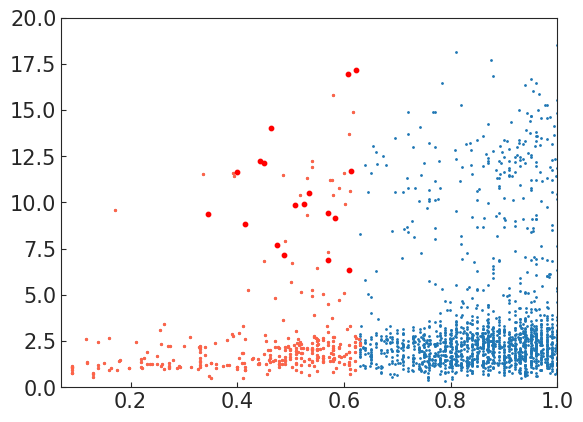

In [55]:
pl.scatter(df_transit['st_mass'], df_transit['pl_rade'], s=1)
pl.scatter(df_M['st_mass'], df_M['pl_rade'], s=2, color='tomato')
pl.scatter(df_sel['Stellar Mass (M_Sun)'], df_sel['Planet Radius (R_Earth)'], s=10, color='r')
pl.xlim(0.07, 1)
pl.ylim(0, 20)

In [78]:
con=(ascon.R_jup/ascon.R_earth).value

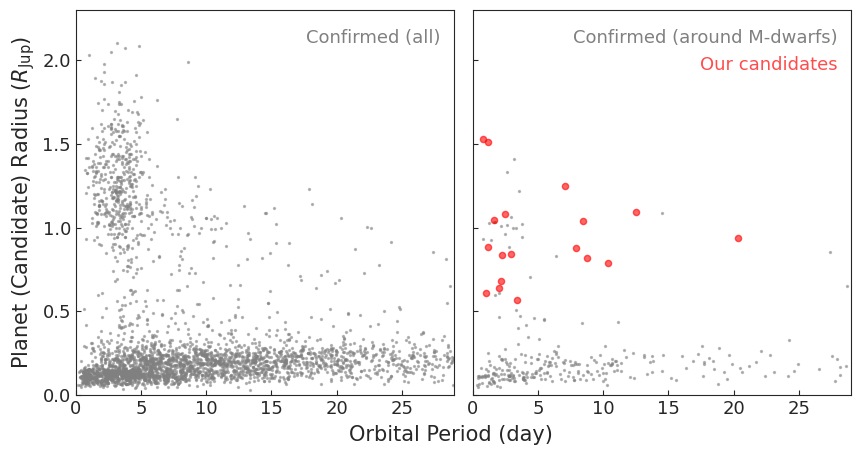

In [121]:
f, axs = pl.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
pl.subplots_adjust(wspace=0.05)
axs[0].scatter(df_all['pl_orbper'], df_all['pl_rade']/con, s=2, color='gray', alpha=0.5)
axs[1].scatter(df_M['pl_orbper'], df_M['pl_rade']/con, s=2, color='gray', alpha=0.5)
axs[1].scatter(df_sel['Period (days)'], df_sel['Planet Radius (R_Earth)']/con, s=20, color='r', alpha=0.6)
axs[0].set_xlim(0, 29)
axs[0].set_ylim(0, 2.3)
axs[0].set_ylabel(r'Planet (Candidate) Radius ($R_{\rm Jup}$)', fontsize=15)
f.supxlabel(r'Orbital Period (day)', fontsize=15)
axs[0].text(28, 2.1, 'Confirmed (all)', ha='right', color='gray', fontsize=13)
axs[1].text(28, 2.1, 'Confirmed (around M-dwarfs)', ha='right', color='gray', fontsize=13)
axs[1].text(28, 1.94, 'Our candidates', ha='right', color='red', alpha=0.7, fontsize=13)
f.savefig('Proposal_example.pdf', bbox_inches='tight')

Distribution of orbital period versus planet radius for confirmed transiting systems, cropped to the axis ranges shown in the figure.
Gray dots in the left panel represent planets orbiting all host stars, while gray dots in the right panel show planets around M dwarfs, defined here as 𝑀⋆<0.3𝑀⊙. Red points mark the planetary candidates proposed in this study. Confirmed planet data are taken from the NASA Exoplanet Archive (as of 2023-12-31), and candidate information is from the ExoFOP.